# Strategie di investimento MST: 4 metodi, costi, tasse e grafici MST per settore

Questo notebook:

1. carica rendimenti, controvalore scambiato, capitalizzazioni e anagrafica società;
2. costruisce i MST con i 4 metodi;
3. genera immagini dei MST con nodi colorati per settore e legenda;
4. costruisce strategie di portafoglio basate su degree centrality;
5. confronta le strategie con benchmark market-cap;
6. usa il pacchetto `portfolio_backtester` per includere costi di transazione e tassazione sulle plusvalenze realizzate.

In [1]:
import os
import sys
from pathlib import Path

# rende importabile il pacchetto locale portfolio_backtester da notebook.
PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent

SRC_DIR = PROJECT_DIR / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

from portfolio_backtester.mst_methods import (
    build_method1_mst,
    build_method2_mst,
    build_method3_mst,
    build_method4_mst,
    compute_mst_centrality,
)

from portfolio_backtester.strategies import (
    get_latest_market_cap,
    weights_by_degree,
    weights_by_market_cap_for_selected_symbols,
    weights_top_market_cap,
)

from portfolio_backtester.backtest import (
    BacktestConfig,
    PortfolioBacktester,
)

from portfolio_backtester.metrics import performance_metrics

BASE_DIR = ".."

DATA_DIR = os.path.join(BASE_DIR, "data")
PROCESSED_DIR = os.path.join(DATA_DIR, "processed")
OUTPUTS_DIR = os.path.join(BASE_DIR, "outputs")
FIGURES_DIR = os.path.join(OUTPUTS_DIR, "figures")
TABLES_DIR = os.path.join(OUTPUTS_DIR, "tables")
MST_FIGURES_DIR = os.path.join(FIGURES_DIR, "mst_all_methods_by_year")

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(TABLES_DIR, exist_ok=True)
os.makedirs(MST_FIGURES_DIR, exist_ok=True)

In [2]:
returns_path = os.path.join(
    PROCESSED_DIR,
    "returns_final_for_mst_italy_2015_2024.csv"
)

traded_money_path = os.path.join(
    PROCESSED_DIR,
    "traded_money_matrix_italy_2015_2024.csv"
)

market_cap_path = os.path.join(
    PROCESSED_DIR,
    "market_cap_matrix_italy_2015_2024.csv"
)

company_info_path = os.path.join(
    PROCESSED_DIR,
    "company_info_italy_2015_2024.csv"
)

returns_log = pd.read_csv(returns_path, index_col=0, parse_dates=True).sort_index()
traded_money = pd.read_csv(traded_money_path, index_col=0, parse_dates=True).sort_index()
market_cap = pd.read_csv(market_cap_path, index_col=0, parse_dates=True).sort_index()
company_info = pd.read_csv(company_info_path)

# Per il backtest servono rendimenti semplici.
# I MST sono invece costruiti sui log-rendimenti, come nel paper.
returns_simple = np.exp(returns_log) - 1

common_symbols = sorted(
    set(returns_log.columns)
    .intersection(traded_money.columns)
    .intersection(market_cap.columns)
)

returns_log = returns_log[common_symbols]
returns_simple = returns_simple[common_symbols]
traded_money = traded_money[common_symbols]
market_cap = market_cap[common_symbols]

common_dates = returns_log.index.intersection(traded_money.index)

returns_log = returns_log.loc[common_dates]
returns_simple = returns_simple.loc[common_dates]
traded_money = traded_money.loc[common_dates]

print("Rendimenti log:", returns_log.shape)
print("Rendimenti semplici:", returns_simple.shape)
print("Controvalore:", traded_money.shape)
print("Market cap:", market_cap.shape)
print("Company info columns:", company_info.columns.tolist())
company_info.head()

Rendimenti log: (2424, 37)
Rendimenti semplici: (2424, 37)
Controvalore: (2424, 37)
Market cap: (2543, 37)
Company info columns: ['symbol', 'yahoo_ticker', 'name', 'sector']


,symbol,yahoo_ticker,name,sector
0,A2A,A2A.MI,A2A,Utilities
1,AMP,AMP.MI,Amplifon,Healthcare
2,AZM,AZM.MI,Azimut,Financial Services
3,BAMI,BAMI.MI,Banco BPM,Banking
4,BC,BC.MI,Brunello Cucinelli,Consumer Goods


In [3]:
# Parametri strategia/MST
X = 10
TRAINING_YEARS = 3
START_INVEST_YEAR = 2018
END_INVEST_YEAR = 2024
MIN_PERIODS_CORR = 93

# Parametri backtest con costi e tasse
INITIAL_CAPITAL = 100_000.0
TRANSACTION_FIXED_COST = 5.0
TRANSACTION_RATE = 0.0
CAPITAL_GAIN_TAX_RATE = 0.26
RISK_FREE_RATE = 0.0

# Se True, mostra tutti i MST nel notebook.
# Se False, li salva solo su file: più comodo perché sono 4 metodi x 7 anni = 28 immagini.
SHOW_MST_PLOTS = False

config = BacktestConfig(
    initial_capital=INITIAL_CAPITAL,
    transaction_fixed_cost=TRANSACTION_FIXED_COST,
    transaction_rate=TRANSACTION_RATE,
    capital_gain_tax_rate=CAPITAL_GAIN_TAX_RATE,
    min_trade_value=1.0,
    use_tax_loss_carryforward=True,
    fill_missing_returns_with_zero=True,
)

config

BacktestConfig(initial_capital=100000.0, transaction_fixed_cost=5.0, transaction_rate=0.0, capital_gain_tax_rate=0.26, min_trade_value=1.0, use_tax_loss_carryforward=True, fill_missing_returns_with_zero=True)

In [4]:
# Legenda settori-colori

sector_color_map = {
    "Apparel": ("Dark green", "#006400"),
    "Automobiles": ("Orange", "#ffa500"),
    "Automobiles Trucks": ("Orange", "#ffa500"),
    "Banking": ("Pink", "#ff69b4"),
    "Business services": ("Dark red", "#8b0000"),
    "Communication": ("Light green", "#90ee90"),
    "Telecommunications": ("Light green", "#90ee90"),
    "Construction": ("Purple", "#800080"),
    "Construction Materials": ("Dark purple", "#4b0082"),
    "Construction materials": ("Dark purple", "#4b0082"),
    "Consumer Goods": ("Brown", "#8b4513"),
    "Consumer goods": ("Brown", "#8b4513"),
    "Consumer Products": ("Brown", "#8b4513"),
    "Electronic equipment": ("Green", "#008000"),
    "Industrial Goods": ("Green", "#008000"),
    "Industrials": ("Green", "#008000"),
    "Insurance": ("Red", "#ff0000"),
    "Petroleum and natural gas": ("Gray", "#808080"),
    "Energy": ("Gray", "#808080"),
    "Pharmaceutical products": ("Light blue", "#add8e6"),
    "Healthcare": ("Light blue", "#add8e6"),
    "Printing and publishing": ("Light purple", "#dda0dd"),
    "Trading": ("Blue", "#0000ff"),
    "Financial Services": ("Blue", "#0000ff"),
    "Financial Technology": ("Blue", "#0000ff"),
    "Transportation": ("Orange", "#ffa500"),
    "Transport": ("Orange", "#ffa500"),
    "Utilities": ("Dark blue", "#00008b"),
    "Food Beverage": ("Gold", "#ffd700"),
    "Food": ("Gold", "#ffd700"),
    "Technology": ("White", "#ffffff"),
    "Unknown": ("Light gray", "#cccccc"),
}

DEFAULT_NODE_COLOR = "#cccccc"
DEFAULT_COLOR_NAME = "Light gray"
DEFAULT_COLOR_HEX = "#cccccc"

company_info = company_info.copy()
company_info.columns = [col.strip() for col in company_info.columns]

if "symbol" not in company_info.columns:
    raise ValueError("Nel file company_info manca la colonna 'symbol'.")

if "sector" not in company_info.columns:
    raise ValueError("Nel file company_info manca la colonna 'sector'.")

company_info["symbol"] = company_info["symbol"].astype(str).str.strip()
company_info["sector"] = company_info["sector"].astype(str).str.strip()

symbol_to_sector = company_info.set_index("symbol")["sector"].to_dict()

# creo una legenda solo per i settori effettivamente presenti nel campione.
used_sectors = sorted(company_info["sector"].dropna().unique().tolist())

legend_rows = []
for sector in used_sectors:
    color_name, color_hex = sector_color_map.get(sector, (DEFAULT_COLOR_NAME, DEFAULT_COLOR_HEX))
    legend_rows.append({
        "sector": sector,
        "color_name": color_name,
        "color_hex": color_hex,
    })

sector_legend_df = pd.DataFrame(legend_rows)

sector_legend_path = os.path.join(TABLES_DIR, "sector_color_legend.xlsx")
sector_legend_df.to_excel(sector_legend_path, index=False)

# Salvo anche una legenda grafica come PNG.
fig_height = max(3, 0.35 * len(sector_legend_df))
fig, ax = plt.subplots(figsize=(7, fig_height))
ax.axis("off")

legend_handles = [
    mpatches.Patch(
        facecolor=row["color_hex"],
        edgecolor="black",
        label=f'{row["sector"]} ({row["color_name"]})'
    )
    for _, row in sector_legend_df.iterrows()
]

ax.legend(
    handles=legend_handles,
    loc="center left",
    frameon=True,
    title="Legenda settori-colori",
    fontsize=9,
)

sector_legend_png_path = os.path.join(FIGURES_DIR, "sector_color_legend.png")
plt.savefig(sector_legend_png_path, dpi=300, bbox_inches="tight")
plt.close(fig)

print("Legenda salvata in:", sector_legend_path)
print("Legenda PNG salvata in:", sector_legend_png_path)
sector_legend_df

Legenda salvata in: ..\outputs\tables\sector_color_legend.xlsx
Legenda PNG salvata in: ..\outputs\figures\sector_color_legend.png


,sector,color_name,color_hex
0,Automobiles,Orange,#ffa500
1,Banking,Pink,#ff69b4
2,Construction Materials,Dark purple,#4b0082
3,Consumer Goods,Brown,#8b4513
4,Energy,Gray,#808080
5,Financial Services,Blue,#0000ff
6,Food Beverage,Gold,#ffd700
7,Healthcare,Light blue,#add8e6
8,Industrials,Green,#008000
9,Insurance,Red,#ff0000


In [5]:
def get_color_hex(color_value):
    """
    Gestisce sia:
    - "#ff69b4"
    - ("Pink", "#ff69b4")
    """

    if isinstance(color_value, tuple):
        return color_value[1]

    return color_value


def get_color_name(color_value):
    """
    Restituisce il nome del colore se disponibile.
    """

    if isinstance(color_value, tuple):
        return color_value[0]

    return str(color_value)


def draw_mst_by_sector(
    mst,
    year,
    method_number,
    figures_dir,
    show=False
):
    """
    Disegna e salva il MST con nodi colorati per settore.
    """

    sector_map = company_info.set_index("symbol")["sector"].to_dict()

    nodes = list(mst.nodes())

    node_colors = []
    node_sectors = []

    for node in nodes:
        sector = sector_map.get(node, "Unknown")

        color_value = sector_color_map.get(
            sector,
            DEFAULT_NODE_COLOR
        )

        color_hex = get_color_hex(color_value)

        node_sectors.append(sector)
        node_colors.append(color_hex)

    plt.figure(figsize=(18, 10))

    pos = nx.spring_layout(
        mst,
        seed=42,
        k=0.8,
        iterations=200
    )

    nx.draw_networkx_edges(
        mst,
        pos,
        alpha=0.5,
        width=1.2,
        edge_color="gray"
    )

    nx.draw_networkx_nodes(
        mst,
        pos,
        node_color=node_colors,
        node_size=700,
        alpha=0.95,
        edgecolors="black",
        linewidths=0.7
    )

    nx.draw_networkx_labels(
        mst,
        pos,
        font_size=9,
        font_weight="bold"
    )

    used_sectors = sorted(set(node_sectors))

    legend_handles = []

    for sector in used_sectors:
        color_value = sector_color_map.get(
            sector,
            DEFAULT_NODE_COLOR
        )

        color_hex = get_color_hex(color_value)
        color_name = get_color_name(color_value)

        legend_handles.append(
            mpatches.Patch(
                facecolor=color_hex,
                edgecolor="black",
                label=f"{sector} ({color_name})"
            )
        )

    plt.legend(
        handles=legend_handles,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=9,
        title="Settori"
    )

    plt.title(
        f"Minimum Spanning Tree - Metodo {method_number}\n"
        f"Anno investimento {year}, nodi colorati per settore",
        fontsize=14
    )

    plt.axis("off")

    output_path = os.path.join(
        figures_dir,
        f"mst_method{method_number}_{year}_colored_by_sector.png"
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    if show:
        plt.show()
    else:
        plt.close()

    return output_path

In [6]:
def first_trading_day_on_or_after(index, date):
    """
    Trova il primo giorno di borsa disponibile uguale o successivo alla data richiesta.
    """
    date = pd.Timestamp(date)
    available_dates = index[index >= date]

    if len(available_dates) == 0:
        return None

    return available_dates.min()


method_builders = {
    1: lambda r, m: build_method1_mst(
        r,
        min_periods=MIN_PERIODS_CORR
    ),
    2: lambda r, m: build_method2_mst(
        r,
        min_periods=MIN_PERIODS_CORR
    ),
    3: lambda r, m: build_method3_mst(
        r,
        m,
        min_periods=MIN_PERIODS_CORR
    ),
    4: lambda r, m: build_method4_mst(
        r,
        m,
        min_periods=MIN_PERIODS_CORR
    ),
}

In [7]:
strategy_schedules = {}

for method_number in [1, 2, 3, 4]:
    strategy_schedules[f"MST_method{method_number}_degree_weighted"] = {}
    strategy_schedules[f"MST_method{method_number}_market_cap_same_X"] = {}

strategy_schedules["Top_market_cap_weighted"] = {}

all_selected = []
all_centralities = []
all_mst_figures = []

for year in range(START_INVEST_YEAR, END_INVEST_YEAR + 1):

    train_start = pd.Timestamp(f"{year - TRAINING_YEARS}-01-01")
    train_end = pd.Timestamp(f"{year}-01-01")

    rebalance_date = first_trading_day_on_or_after(
        returns_simple.index,
        f"{year}-01-01"
    )

    if rebalance_date is None:
        continue

    returns_train = returns_log.loc[
        (returns_log.index >= train_start) &
        (returns_log.index < train_end)
    ]

    money_train = traded_money.loc[
        (traded_money.index >= train_start) &
        (traded_money.index < train_end)
    ]

    caps = get_latest_market_cap(
        market_cap,
        rebalance_date
    )

    print(f"Anno investimento: {year}")
    print(f"Data ribilanciamento: {rebalance_date.date()}")
    print(f"Training: {train_start.date()} - {(train_end - pd.Timedelta(days=1)).date()}")

    # Benchmark tradizionale:
    # prime X società per capitalizzazione, pesate per capitalizzazione.
    w_top_cap = weights_top_market_cap(caps, X)
    strategy_schedules["Top_market_cap_weighted"][rebalance_date] = w_top_cap

    print("Benchmark top market cap:", list(w_top_cap.index))

    # Strategie MST per i quattro metodi.
    for method_number, builder in method_builders.items():

        print(f"Metodo {method_number}...")

        mst, corr_matrix, distance_matrix = builder(
            returns_train,
            money_train
        )

        # Salvo immagine MST colorata per settore.
        mst_figure_path = draw_mst_by_sector(
            mst=mst,
            year=year,
            method_number=method_number,
            figures_dir=MST_FIGURES_DIR,
            show=SHOW_MST_PLOTS,
        )

        all_mst_figures.append({
            "year": year,
            "method": method_number,
            "figure_path": mst_figure_path,
        })

        centrality = compute_mst_centrality(mst)

        centrality["year"] = year
        centrality["method"] = method_number
        centrality["rebalance_date"] = rebalance_date

        all_centralities.append(centrality)

        # Strategia MST:
        # top X per degree, pesati per degree.
        w_degree = weights_by_degree(
            centrality,
            X
        )

        selected_symbols = list(w_degree.index)

        # Stessi titoli selezionati dal MST,
        # ma pesati per capitalizzazione.
        w_cap_same_x = weights_by_market_cap_for_selected_symbols(
            selected_symbols,
            caps
        )

        strategy_schedules[
            f"MST_method{method_number}_degree_weighted"
        ][rebalance_date] = w_degree

        strategy_schedules[
            f"MST_method{method_number}_market_cap_same_X"
        ][rebalance_date] = w_cap_same_x

        selected_tmp = centrality.head(X).copy()
        selected_tmp["strategy"] = f"MST_method{method_number}_degree_weighted"

        all_selected.append(selected_tmp)

        print("Top MST:", selected_symbols)

mst_figures_df = pd.DataFrame(all_mst_figures)
mst_figures_df.to_excel(
    os.path.join(TABLES_DIR, "mst_figures_all_methods_by_year.xlsx"),
    index=False,
)

print("Figure MST salvate in:", MST_FIGURES_DIR)
mst_figures_df.head()

Anno investimento: 2018
Data ribilanciamento: 2018-01-02
Training: 2015-01-01 - 2017-12-31
Benchmark top market cap: ['BMPS', 'ENEL', 'ENI', 'ISP', 'UCG', 'G', 'RACE', 'TIT', 'SRG', 'TRN']
Metodo 1...
Top MST: ['TRN', 'ISP', 'ENEL', 'PRY', 'MB', 'BMED', 'G', 'AZM', 'ENI', 'BPE']
Metodo 2...
Top MST: ['ISP', 'TRN', 'ENI', 'MB', 'ENEL', 'UNI', 'BZU', 'STLAM', 'AZM', 'G']
Metodo 3...
Top MST: ['ISP', 'TRN', 'ENI', 'ENEL', 'BMED', 'MB', 'RACE', 'AZM', 'STLAM', 'BPE']
Metodo 4...
Top MST: ['ISP', 'ENEL', 'TRN', 'AZM', 'ENI', 'BMED', 'IP', 'BPE', 'RACE', 'TEN']
Anno investimento: 2019
Data ribilanciamento: 2019-01-02
Training: 2016-01-01 - 2018-12-31
Benchmark top market cap: ['ENEL', 'ENI', 'BMPS', 'ISP', 'G', 'UCG', 'RACE', 'SRG', 'TEN', 'TRN']
Metodo 1...
Top MST: ['ISP', 'TRN', 'PRY', 'ENEL', 'MB', 'RACE', 'ENI', 'BPE', 'IP', 'G']
Metodo 2...
Top MST: ['TRN', 'ENI', 'ISP', 'ENEL', 'RACE', 'MB', 'PRY', 'BMED', 'STLAM', 'UCG']
Metodo 3...
Top MST: ['ISP', 'RACE', 'TRN', 'ENI', 'ENEL', 'G',

,year,method,figure_path
0,2018,1,..\outputs\figures\mst_all_methods_by_year\mst...
1,2018,2,..\outputs\figures\mst_all_methods_by_year\mst...
2,2018,3,..\outputs\figures\mst_all_methods_by_year\mst...
3,2018,4,..\outputs\figures\mst_all_methods_by_year\mst...
4,2019,1,..\outputs\figures\mst_all_methods_by_year\mst...


In [8]:
centralities_df = pd.concat(
    all_centralities,
    ignore_index=True
)

selected_df = pd.concat(
    all_selected,
    ignore_index=True
)

company_info_for_merge = company_info.rename(
    columns={"symbol": "Symbol"}
)

centralities_df = centralities_df.merge(
    company_info_for_merge,
    on="Symbol",
    how="left"
)

selected_df = selected_df.merge(
    company_info_for_merge,
    on="Symbol",
    how="left"
)

centralities_df.to_excel(
    os.path.join(
        TABLES_DIR,
        "rolling_centralities_all_methods_with_costs_taxes.xlsx"
    ),
    index=False
)

selected_df.to_excel(
    os.path.join(
        TABLES_DIR,
        "mst_selected_stocks_all_methods_with_costs_taxes.xlsx"
    ),
    index=False
)

selected_df.head()

,Symbol,degree,degree_centrality,betweenness,closeness,year,method,rebalance_date,strategy,yahoo_ticker,name,sector
0,TRN,8,0.222222,0.438095,0.402173,2018,1,2018-01-02,MST_method1_degree_weighted,TRN.MI,Terna,Utilities
1,ISP,6,0.166667,0.742857,0.496023,2018,1,2018-01-02,MST_method1_degree_weighted,ISP.MI,Intesa Sanpaolo,Banking
2,ENEL,4,0.111111,0.557143,0.459373,2018,1,2018-01-02,MST_method1_degree_weighted,ENEL.MI,Enel,Utilities
3,PRY,4,0.111111,0.161905,0.371669,2018,1,2018-01-02,MST_method1_degree_weighted,PRY.MI,Prysmian,Industrials
4,MB,3,0.083333,0.379365,0.431517,2018,1,2018-01-02,MST_method1_degree_weighted,MB.MI,Mediobanca,Banking


In [9]:
all_daily_returns = {}
all_daily_values = {}
all_trades = []
all_taxes = []

start_date = first_trading_day_on_or_after(
    returns_simple.index,
    f"{START_INVEST_YEAR}-01-01"
)

end_date = returns_simple.index[
    returns_simple.index <= pd.Timestamp(f"{END_INVEST_YEAR}-12-31")
].max()

for strategy_name, schedule in strategy_schedules.items():

    print("Backtest:", strategy_name)

    backtester = PortfolioBacktester(
        returns_simple=returns_simple,
        config=config
    )

    result = backtester.run(
        target_weights_by_date=schedule,
        start_date=start_date,
        end_date=end_date,
        strategy_name=strategy_name
    )

    daily = result["daily"].copy()
    trades = result["trades"].copy()
    taxes = result["taxes"].copy()

    all_daily_returns[strategy_name] = daily["portfolio_return"]
    all_daily_values[strategy_name] = daily["portfolio_value"]

    if not trades.empty:
        trades["strategy"] = strategy_name
        all_trades.append(trades)

    if not taxes.empty:
        taxes["strategy"] = strategy_name
        all_taxes.append(taxes)

portfolio_returns_df = pd.DataFrame(
    all_daily_returns
).sort_index()

portfolio_values_df = pd.DataFrame(
    all_daily_values
).sort_index()

portfolio_returns_df.to_csv(
    os.path.join(
        PROCESSED_DIR,
        "portfolio_returns_all_methods_with_costs_taxes.csv"
    )
)

portfolio_values_df.to_csv(
    os.path.join(
        PROCESSED_DIR,
        "portfolio_values_all_methods_with_costs_taxes.csv"
    )
)

portfolio_returns_df.head()

Backtest: MST_method1_degree_weighted
Backtest: MST_method1_market_cap_same_X
Backtest: MST_method2_degree_weighted
Backtest: MST_method2_market_cap_same_X
Backtest: MST_method3_degree_weighted
Backtest: MST_method3_market_cap_same_X
Backtest: MST_method4_degree_weighted
Backtest: MST_method4_market_cap_same_X
Backtest: Top_market_cap_weighted


,MST_method1_degree_weighted,MST_method1_market_cap_same_X,MST_method2_degree_weighted,MST_method2_market_cap_same_X,MST_method3_degree_weighted,MST_method3_market_cap_same_X,MST_method4_degree_weighted,MST_method4_market_cap_same_X,Top_market_cap_weighted
date,,,,,,,,,
2018-01-02,-0.007485,-0.005184,0.000867,-0.004058,-0.004986,-0.003926,-0.004145,-0.003587,-0.003727
2018-01-03,-0.001893,-0.001179,0.001117,-0.001401,0.000697,0.000929,0.000777,0.001502,-0.000941
2018-01-04,0.021542,0.023498,0.026261,0.023573,0.027030,0.026817,0.026605,0.027942,0.022422
2018-01-05,0.010009,0.010775,0.013268,0.010602,0.013379,0.010436,0.009535,0.010670,0.004620
2018-01-08,-0.000910,0.000221,0.001356,0.000344,0.000547,0.001190,0.000015,0.001009,0.001308


In [10]:
trades_df = (
    pd.concat(all_trades, ignore_index=True)
    if len(all_trades) > 0
    else pd.DataFrame()
)

taxes_df = (
    pd.concat(all_taxes, ignore_index=True)
    if len(all_taxes) > 0
    else pd.DataFrame()
)

trades_df.to_excel(
    os.path.join(
        TABLES_DIR,
        "portfolio_trades_all_methods_with_costs_taxes.xlsx"
    ),
    index=False
)

taxes_df.to_excel(
    os.path.join(
        TABLES_DIR,
        "portfolio_taxes_all_methods_with_costs_taxes.xlsx"
    ),
    index=False
)

print("Trade log salvato:", trades_df.shape)
print("Tax log salvato:", taxes_df.shape)
trades_df.head()

Trade log salvato: (779, 11)
Tax log salvato: (358, 9)


,date,symbol,side,trade_value,transaction_cost,basis_sold,realized_gain_after_costs,tax_paid,cash_after,portfolio_value_after,strategy
0,2018-01-02,TRN,BUY,19990.00,5.0,0.0,0.0,0.0,80005.00,99995.0,MST_method1_degree_weighted
1,2018-01-02,ISP,BUY,14992.50,5.0,0.0,0.0,0.0,65007.50,99990.0,MST_method1_degree_weighted
2,2018-01-02,ENEL,BUY,9995.00,5.0,0.0,0.0,0.0,55007.50,99985.0,MST_method1_degree_weighted
3,2018-01-02,PRY,BUY,9995.00,5.0,0.0,0.0,0.0,45007.50,99980.0,MST_method1_degree_weighted
4,2018-01-02,MB,BUY,7496.25,5.0,0.0,0.0,0.0,37506.25,99975.0,MST_method1_degree_weighted


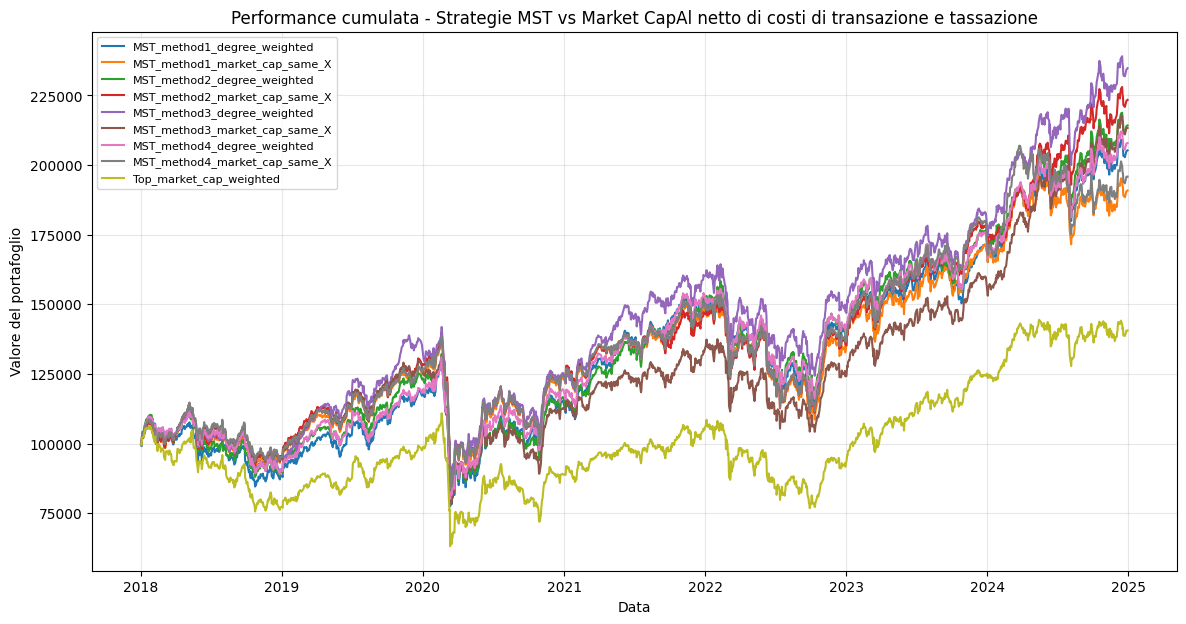

In [11]:
plt.figure(figsize=(14, 7))

for col in portfolio_values_df.columns:
    plt.plot(
        portfolio_values_df.index,
        portfolio_values_df[col],
        label=col
    )

plt.title(
    "Performance cumulata - Strategie MST vs Market Cap"
    "Al netto di costi di transazione e tassazione"
)

plt.ylabel("Valore del portafoglio")
plt.xlabel("Data")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)

plt.savefig(
    os.path.join(
        FIGURES_DIR,
        "portfolio_cumulative_performance_all_methods_with_costs_taxes.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
metrics_df = performance_metrics(
    portfolio_returns_df,
    risk_free_rate=RISK_FREE_RATE
)

metrics_df = metrics_df.sort_values(
    "sharpe_ratio",
    ascending=False
)

metrics_df.to_excel(
    os.path.join(
        TABLES_DIR,
        "portfolio_performance_metrics_all_methods_with_costs_taxes.xlsx"
    ),
    index=False
)

metrics_df

,strategy,total_return,annual_return,annual_volatility,sharpe_ratio,max_drawdown,n_days
4,MST_method3_degree_weighted,1.347728,0.128581,0.200706,0.640643,-0.397187,1778
3,MST_method2_market_cap_same_X,1.233979,0.120665,0.203057,0.594242,-0.400929,1778
5,MST_method3_market_cap_same_X,1.133314,0.113365,0.202239,0.560552,-0.406205,1778
2,MST_method2_degree_weighted,1.142133,0.114016,0.204380,0.557865,-0.396454,1778
6,MST_method4_degree_weighted,1.078952,0.109300,0.197831,0.552489,-0.388698,1778
0,MST_method1_degree_weighted,1.052517,0.107289,0.206797,0.518816,-0.409070,1778
7,MST_method4_market_cap_same_X,0.958442,0.099951,0.204595,0.488528,-0.398765,1778
1,MST_method1_market_cap_same_X,0.908380,0.095921,0.204133,0.469895,-0.408657,1778
8,Top_market_cap_weighted,0.405972,0.049477,0.211095,0.234385,-0.430663,1778


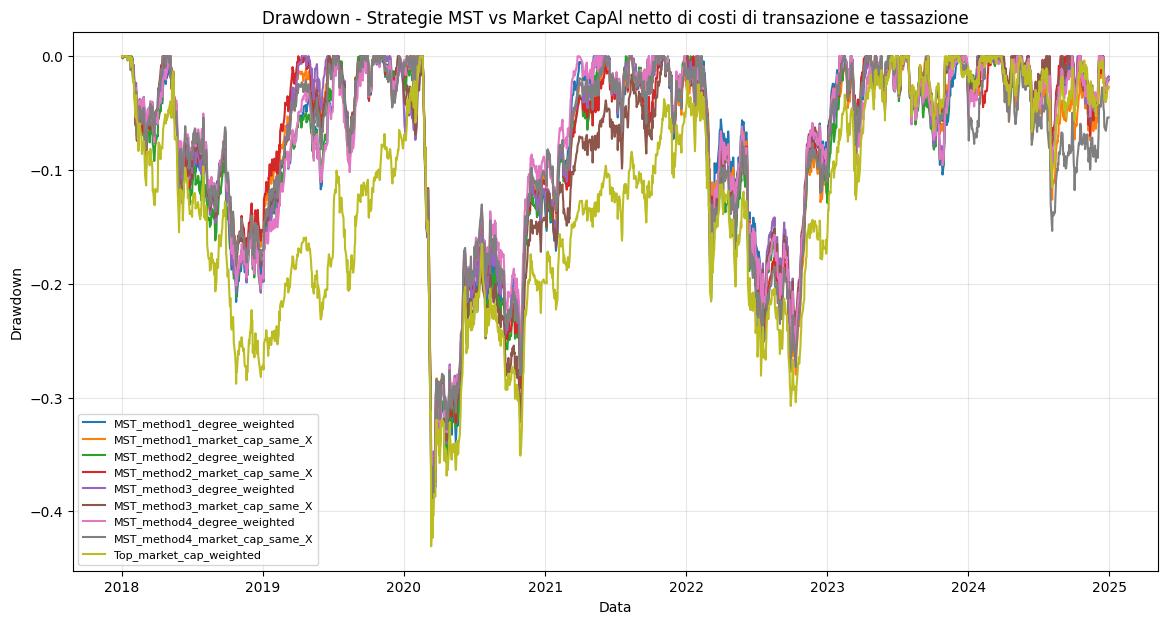

In [13]:
drawdowns = portfolio_values_df / portfolio_values_df.cummax() - 1

plt.figure(figsize=(14, 7))

for col in drawdowns.columns:
    plt.plot(
        drawdowns.index,
        drawdowns[col],
        label=col
    )

plt.title(
    "Drawdown - Strategie MST vs Market Cap"
    "Al netto di costi di transazione e tassazione"
)

plt.ylabel("Drawdown")
plt.xlabel("Data")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)

plt.savefig(
    os.path.join(
        FIGURES_DIR,
        "portfolio_drawdowns_all_methods_with_costs_taxes.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
annual_returns = (
    portfolio_returns_df
    .add(1)
    .resample("YE")
    .prod()
    .sub(1)
)

annual_returns.index = annual_returns.index.year

annual_returns.to_excel(
    os.path.join(
        TABLES_DIR,
        "portfolio_annual_returns_all_methods_with_costs_taxes.xlsx"
    )
)

annual_returns

,MST_method1_degree_weighted,MST_method1_market_cap_same_X,MST_method2_degree_weighted,MST_method2_market_cap_same_X,MST_method3_degree_weighted,MST_method3_market_cap_same_X,MST_method4_degree_weighted,MST_method4_market_cap_same_X,Top_market_cap_weighted
date,,,,,,,,,
2018,-0.116653,-0.058811,-0.103382,-0.044609,-0.092748,-0.054217,-0.095990,-0.048245,-0.229144
2019,0.326218,0.326210,0.372157,0.340563,0.492201,0.347545,0.306999,0.318209,0.265320
2020,-0.018008,-0.012986,-0.054138,-0.029519,-0.076609,-0.117769,0.009684,-0.011211,-0.089708
2021,0.318718,0.207408,0.302258,0.182168,0.280871,0.184068,0.286632,0.209636,0.182482
2022,-0.082049,-0.107753,-0.074708,-0.076691,-0.078528,-0.067523,-0.083767,-0.090262,-0.127176
2023,0.227811,0.288169,0.253415,0.310878,0.237859,0.285997,0.247070,0.315520,0.357931
2024,0.200408,0.116196,0.218810,0.256130,0.285430,0.336237,0.185386,0.090510,0.129857


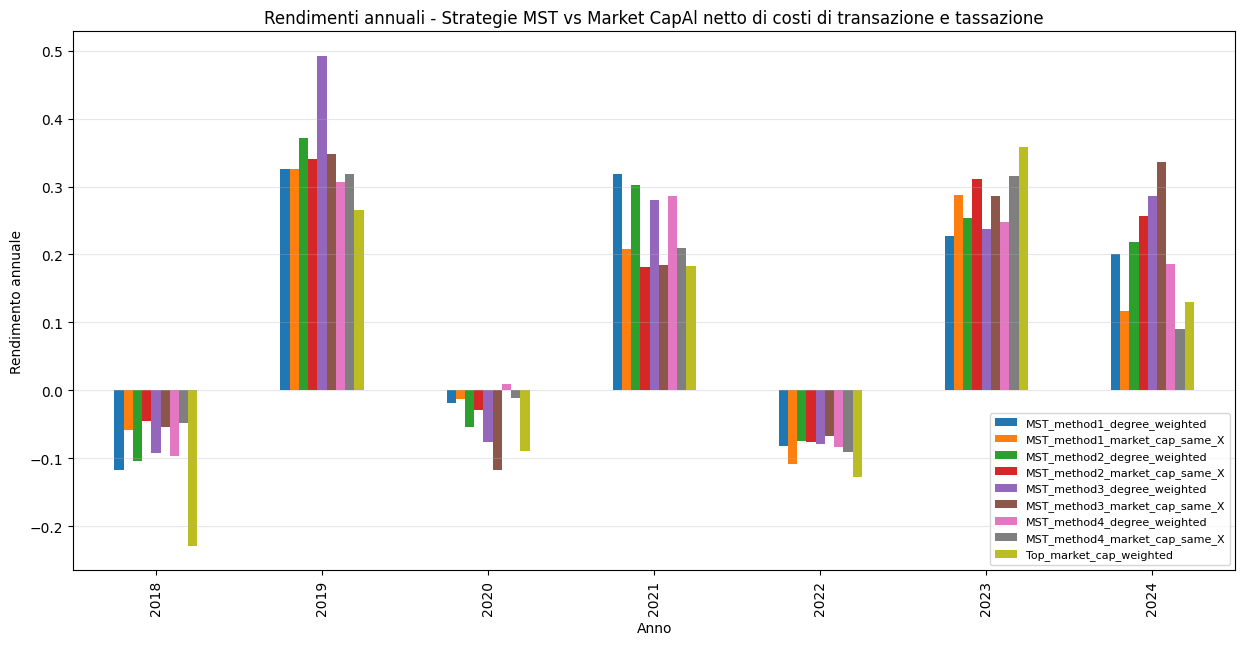

In [15]:
annual_returns.plot(
    kind="bar",
    figsize=(15, 7)
)

plt.title(
    "Rendimenti annuali - Strategie MST vs Market Cap"
    "Al netto di costi di transazione e tassazione"
)

plt.ylabel("Rendimento annuale")
plt.xlabel("Anno")
plt.grid(True, axis="y", alpha=0.3)
plt.legend(fontsize=8)

plt.savefig(
    os.path.join(
        FIGURES_DIR,
        "portfolio_annual_returns_all_methods_with_costs_taxes.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [16]:
final_summary = metrics_df.copy()

for col in [
    "total_return",
    "annual_return",
    "annual_volatility",
    "sharpe_ratio",
    "max_drawdown"
]:
    final_summary[col] = final_summary[col].round(4)

final_summary.to_excel(
    os.path.join(
        TABLES_DIR,
        "portfolio_final_summary_all_methods_with_costs_taxes_for_thesis.xlsx"
    ),
    index=False
)

final_summary

,strategy,total_return,annual_return,annual_volatility,sharpe_ratio,max_drawdown,n_days
4,MST_method3_degree_weighted,1.3477,0.1286,0.2007,0.6406,-0.3972,1778
3,MST_method2_market_cap_same_X,1.2340,0.1207,0.2031,0.5942,-0.4009,1778
5,MST_method3_market_cap_same_X,1.1333,0.1134,0.2022,0.5606,-0.4062,1778
2,MST_method2_degree_weighted,1.1421,0.1140,0.2044,0.5579,-0.3965,1778
6,MST_method4_degree_weighted,1.0790,0.1093,0.1978,0.5525,-0.3887,1778
0,MST_method1_degree_weighted,1.0525,0.1073,0.2068,0.5188,-0.4091,1778
7,MST_method4_market_cap_same_X,0.9584,0.1000,0.2046,0.4885,-0.3988,1778
1,MST_method1_market_cap_same_X,0.9084,0.0959,0.2041,0.4699,-0.4087,1778
8,Top_market_cap_weighted,0.4060,0.0495,0.2111,0.2344,-0.4307,1778
